# MOM 3D Plate - Mesh Iterate 

## Import Packages

In [4]:
try
    using Gmsh: Gmsh, gmsh
catch
    using gmsh
end 

using LinearAlgebra  # provides linear algebra toolas 
using StaticArrays   # provides statically typed arrays 
using HCubature      # provides adaptive numerical integration 

using Test           # provides testing functionality 

using Plots          # provides plotting functionality 

const Point3D = SVector{3,Float64};

include("mesh_struct_definitions.jl");

## Section 1: Introduction 

We iterate over elements in the mesh. 

## Section 2: Read Mesh from File and Iterate over the Elements   

<b>Exercises</b>
1. extend code below to recover faces, edges and node labels belonging to an element. In GMSH, this is referred to as the element adjacency. See <i>gmsh.model.getAdjacencies(dim, tag)</i>.   

In [65]:
Gmsh.finalize()

In [66]:
#..1/7: Finalize gmsh
should_finalize = Gmsh.initialize()

#..2/7: Read mesh from file
gmsh.open("metallic_plate_3d.msh")

#..3/7: Get all the 3D tetrahedral elements (dim=3) in the plate (tag=1) 
#..we previously made sure to have a single elemType only 
dim = 3; tag = 1
elem_types, element_tags, node_tags = gmsh.model.mesh.getElements(dim, tag)

#..4/7: Reshape the flat node_tags array - convenient for later  
nelements = length(element_tags[1])
nodes_per_element = reshape(node_tags[1], 4, nelements) # 4 rows, N columns

#..5/7: Get number of nodes 
node_tags,_,_ = gmsh.model.mesh.getNodes()
nnodes = length(node_tags)

#..6/7: Loop over elements - requires more explanation 
for (i,element_tag) in enumerate(element_tags[1])

    #....Extract individual node tags for this element 
    node_elem_tags = Int64.(nodes_per_element[:, i])
    node_elem_tags = hcat(node_elem_tags,node_elem_tags.+nnodes,node_elem_tags.+2*nnodes)
    
    #....Get nodal coordinates 
    # gmsh.model.mesh.getNode returns: (coord, parametricCoord, dim, tag)
    p1, _, _, _ = gmsh.model.mesh.getNode(node_elem_tags[1])
    p2, _, _, _ = gmsh.model.mesh.getNode(node_elem_tags[2])
    p3, _, _, _ = gmsh.model.mesh.getNode(node_elem_tags[3])
    p4, _, _, _ = gmsh.model.mesh.getNode(node_elem_tags[4])

    # Call the type-stable core function
    elem_vol = evalVol(p1, p2, p3, p4)

    if(false)
      println("  elemtag = element_tag",element_tag)  
      println("    elemnode1tag  = ",node_elem_tags[1]) 
      println("      coord node1 = ",p1)
      println("    elemnode2tag  = ",node_elem_tags[2]) 
      println("      coord node2 = ",p2)
      println("    elemnode3tag  = ",node_elem_tags[3]) 
      println("      coord node3 = ",p3)
      println("    elemnode4tag  = ",node_elem_tags[4]) 
      println("      coord node4 = ",p4)
      println("    tetrahedron ID $element_tag | Volume: $elem_vol")
    end 
    
end 

#..7/7: finalize gmsh 
should_finalize && Gmsh.finalize() 

Info    : Reading 'metallic_plate_3d.msh'...
Info    : 27 entities
Info    : 108 nodes
Info    : 526 elements
Info    : Done reading 'metallic_plate_3d.msh'


In [67]:
length(node_tags)

108

## Section 3: Functions to Read Mesh from File 

In [68]:
function getMeshFromFile()
    
    #..1/9: Finalize gmsh
    should_finalize = Gmsh.initialize()

    #..2/9: Read mesh from file
    gmsh.open("metallic_plate_3d.msh")

    #..3/9: Get all the 3D tetrahedral elements (dim=3) in the plate (tag=1) 
    #..we previously made sure to have a single elemType only 
    dim = 3; tag = 1
    elem_types, element_tags, node_tags = gmsh.model.mesh.getElements(dim, tag)

    #..4/9: Reshape the flat node_tags array - convenient for later  
    nelems = length(element_tags[1])
    nodes_per_element = reshape(node_tags[1], 4, nelems) # 4 rows, N columns

    #..5/9: Get number of nodes 
    node_tags,_,_ = gmsh.model.mesh.getNodes()
    nnodes = length(node_tags)
    
    #..6/9: Construct uninitialized array of length nelements  
    Elements = Array{Elem3DLin}(undef,nelems)

    #..7/9: Loop over elements - requires more explanation 
    for (i,element_tag) in enumerate(element_tags[1])

        #....Extract individual node tags for this element 
        node_elem_tags = Int64.(nodes_per_element[:, i])
        node_elem_tags = hcat(node_elem_tags,
                              node_elem_tags.+nnodes,
                              node_elem_tags.+2*nnodes)
        
        #....Get nodal coordinates 
        # gmsh.model.mesh.getNode returns: (coord, parametricCoord, dim, tag)
        p1, _, _, _ = gmsh.model.mesh.getNode(node_elem_tags[1])
        p2, _, _, _ = gmsh.model.mesh.getNode(node_elem_tags[2])
        p3, _, _, _ = gmsh.model.mesh.getNode(node_elem_tags[3])
        p4, _, _, _ = gmsh.model.mesh.getNode(node_elem_tags[4])
        
        Emat = genBasis(p1,p2,p3,p4)
    
        # Call the type-stable core function
        elem_vol = evalVol(p1, p2, p3, p4)

        Elements[i] = Elem3DLin(p1,p2,p3,p4,node_elem_tags,Emat,elem_vol)

        if(false)
          println("  elemtag = element_tag",element_tag)  
          println("    elemnode1tag  = ",node_elem_tags[1]) 
          println("      coord node1 = ",p1)
          println("    elemnode2tag  = ",node_elem_tags[2]) 
          println("      coord node2 = ",p2)
          println("    elemnode3tag  = ",node_elem_tags[3]) 
          println("      coord node3 = ",p3)
          println("    elemnode4tag  = ",node_elem_tags[4]) 
          println("      coord node4 = ",p4)
          println("    tetrahedron ID $element_tag | Volume: $elem_vol")
        end 
    
    end 

    #..8/9: finalize gmsh 
    should_finalize && Gmsh.finalize()
    
    #..9/9: set mesh structure 
    dofsperelement = 12 
    mesh = Mesh(nnodes,nelems,dofsperelement,Elements)
    
    return mesh 
    
end 

getMeshFromFile (generic function with 1 method)

In [69]:
mesh = getMeshFromFile();

Info    : Reading 'metallic_plate_3d.msh'...
Info    : 27 entities
Info    : 108 nodes
Info    : 526 elements
Info    : Done reading 'metallic_plate_3d.msh'


In [70]:
@code_warntype getMeshFromFile()

MethodInstance for getMeshFromFile()
  from getMeshFromFile() @ Main In[68]:1
Arguments
  #self#::Core.Const(getMeshFromFile)
Locals
  @_2::Union{Nothing, Tuple{Tuple{Int64, UInt64}, Tuple{Int64, Int64}}}
  @_3::Int64
  @_4::Int64
  mesh::Mesh
  dofsperelement::Int64
  Elements::Vector{Elem3DLin}
  nnodes::Int64
  nodes_per_element::Matrix{UInt64}
  nelems::Int64
  node_tags::Union{Vector{Vector{UInt64}}, Vector{UInt64}}
  element_tags::Vector{Vector{UInt64}}
  elem_types::Vector{Int32}
  tag::Int64
  dim::Int64
  should_finalize::Bool
  @_17::Int64
  @_18::Int64
  @_19::Int64
  @_20::Int64
  @_21::Int64
  element_tag::UInt64
  i::Int64
  elem_vol::Float64
  Emat::SMatrix{4, 4, Float64, 16}
  p4::Vector{Float64}
  p3::Vector{Float64}
  p2::Vector{Float64}
  p1::Vector{Float64}
  node_elem_tags::VecOrMat{Int64}
Body::Mesh
1 ─        Core.NewvarNode(:(mesh))
│          Core.NewvarNode(:(dofsperelement))
│   %3   = Gmsh.initialize::Core.Const(Gmsh.initialize)
│          (should_finalize =

│          (@_19 = Core.getfield(%96, 2))
│   %99  = Base.indexed_iterate(%89, 4, @_19::Core.Const(4))::Core.PartialStruct(Tuple{Int32, Int64}, Any[Int32, Core.Const(5)])
│          Core.getfield(%99, 1)
│   %101 = Gmsh.gmsh.model::Core.Const(Gmsh.gmsh.model)
│   %102 = Base.getproperty(%101, :mesh)::Core.Const(Gmsh.gmsh.model.mesh)
│   %103 = Base.getproperty(%102, :getNode)::Core.Const(Gmsh.gmsh.model.mesh.getNode)
│   %104 = Base.getindex(node_elem_tags::Matrix{Int64}, 3)::Int64
│   %105 = (%103)(%104)::Tuple{Vector{Float64}, Vector{Float64}, Int32, Int32}
│   %106 = Base.indexed_iterate(%105, 1)::Core.PartialStruct(Tuple{Vector{Float64}, Int64}, Any[Vector{Float64}, Core.Const(2)])
│          (p3 = Core.getfield(%106, 1))
│          (@_18 = Core.getfield(%106, 2))
│   %109 = Base.indexed_iterate(%105, 2, @_18::Core.Const(2))::Core.PartialStruct(Tuple{Vector{Float64}, Int64}, Any[Vector{Float64}, Core.Const(3)])
│          Core.getfield(%109, 1)
│          (@_18 = Core.getfield(%109

## Section 4: Iterate Elements to Assemble Scalars

We iterate over the elements, compute volume of each element and verify that sum of all volumes equals volume of $\Omega$. 

In [71]:
# sum all element volumes in the mesh 
sum([elem.vol for elem in mesh.Elements])

0.09999999999999999

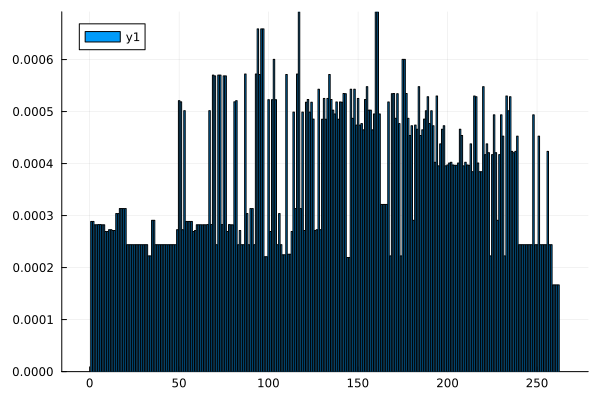

In [72]:
v = [elem.vol for elem in mesh.Elements]
bar(v)

## Section 5: Iterate Elements to Assemble Vectors 

<b>Exercises</b>
1. loop over elements, compute volume of each element and verify that sum of all volumes equals volume of $\Omega$. Turn script into function. Ensure that function is type-stable using e.g. <i>@code_warntype</i>; 
2. loop over elements and assemble the load vector. Turn script into type-stable function;
3. loop over elements and assemble the stiffness and mass matrix. Turn script into type-stable function; 

In [73]:
[mesh.Elements[1].node_elem_tag, genLocVec(mesh.Elements[1])]

2-element Vector{SVector{12, Float64}}:
 [43.0, 14.0, 15.0, 63.0, 151.0, 122.0, 123.0, 171.0, 259.0, 230.0, 231.0, 279.0]
 [7.21687836487032e-5, 7.21687836487032e-5, 7.21687836487032e-5, 7.21687836487032e-5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

In [74]:
#..Initialize vector 
f = zeros(3*mesh.nnodes)

#..Iterate elements 
for element in mesh.Elements
    floc = genLocVec(element)
    f[element.node_elem_tag] += floc 
end 

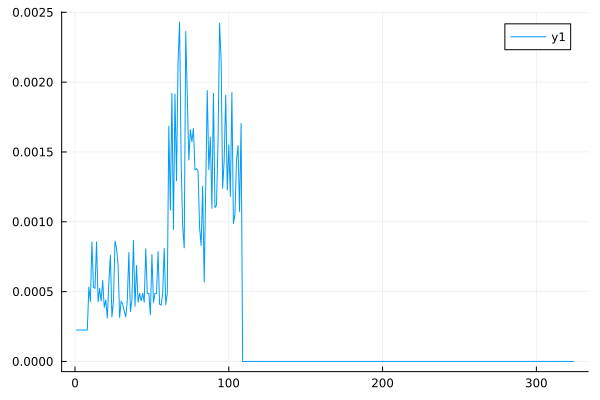

In [75]:
plot(f)

In [76]:
genLocMassMat(mesh.Elements[3]) 

12×12 SMatrix{12, 12, Float64, 144} with indices SOneTo(12)×SOneTo(12):
 2.82304e-5  1.41152e-5  1.41152e-5  …  0.0         0.0         0.0
 1.41152e-5  2.82304e-5  1.41152e-5     0.0         0.0         0.0
 1.41152e-5  1.41152e-5  2.82304e-5     0.0         0.0         0.0
 1.41152e-5  1.41152e-5  1.41152e-5     0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0         …  0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0            0.0         0.0         0.0
 0.0         0.0         0.0            1.41152e-5  1.41152e-5  1.41152e-5
 0.0         0.0         0.0            2.82304e-5  1.41152e-5  1.41152e-5
 0.0         0.0         0.0         …  1.41152e-5  2.82304e-5  1.41152e-5
 0.0         0.0         0.0            1.41152e-5  1.41152e-5  2.82304e-5

In [77]:
#..Initialize vector 
M = zeros(3*mesh.nnodes,3*mesh.nnodes)

#..Iterate elements 
for element in mesh.Elements
    Mloc = genLocMassMat(element)
    M[element.node_elem_tag,element.node_elem_tag] += Mloc 
end 

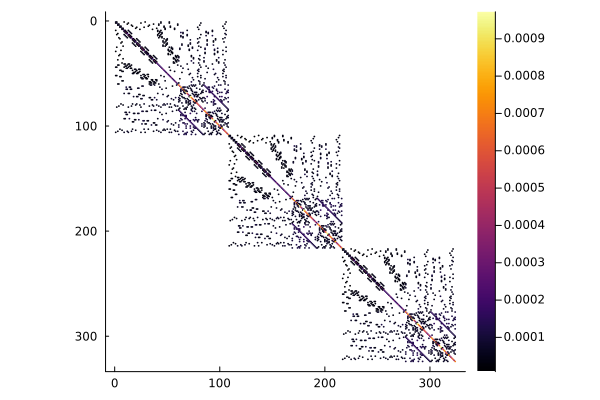

In [78]:
spy(M)

In [111]:
kernel(rd, rs) = 1/(norm(rd - rs)+1e-9); 

In [129]:
function genLocStiffMat(element,elementp)
    
    # define inner integral by integrating over the source domain 
    # thus a function of distination variables remains 
    inner_integral(rd) = integrate_tet(rs->kernel(rd,rs), elementp)

    outer_integral = integrate_tet(rd->inner_integral(rd), element)
    
    v = vcat(element.Emat[:,1],element.Emat[:,2],element.Emat[:,3])

    vp = vcat(elementp.Emat[:,1],elementp.Emat[:,2],elementp.Emat[:,3])
    
    return outer_integral*vp*Transpose(v)
    
end 

genLocStiffMat (generic function with 1 method)

In [130]:
function genStiffMat!(S,mesh)
    
    #..Iterate elements 
    for element in mesh.Elements
        for elementp in mesh.Elements
            Sloc = genLocStiffMat(element, elementp)
            S[elementp.node_elem_tag,element.node_elem_tag] += Sloc 
        end 
    end
    
    return S
    
end 

genStiffMat! (generic function with 1 method)

In [131]:
#..Initialize vector 
S = zeros(3*mesh.nnodes,3*mesh.nnodes)

S = genStiffMat!(S,mesh);

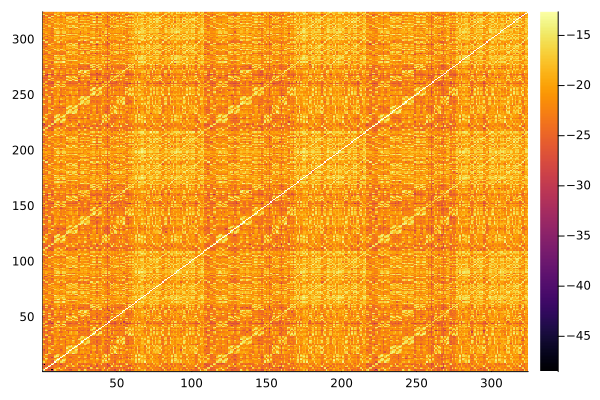

In [137]:
Sxx = S[1:nnodes,1:nnodes]; 
heatmap(log.(abs.(S - Transpose(S))))

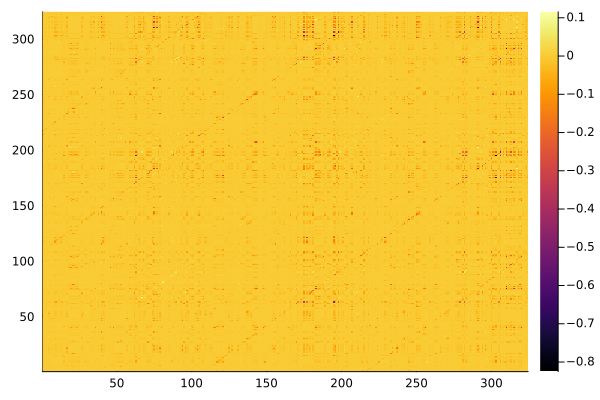

In [123]:
heatmap(S.*((S.>=-1e-6)*(S.<=1e-6)))

In [83]:
#..1/7: Finalize gmsh
should_finalize = Gmsh.initialize()

#..2/7: Read mesh from file
gmsh.open("my_box.msh")

#..initialize matrix 
node_tags, _, _ = gmsh.model.mesh.getNodes()

#..3/7: Get the line mesh entity (this part can be skipped) 
# Get all the elementary entities in the model, as a vector of (dimension, tag) pairs
# In case of line tutorial, return dim = 1 and tag = 1 
# or entities[1] = (1,1)
entities = gmsh.model.getEntities(1)

#..4/7: Get elements 
dim = 3 
tag = 1
elemTypes, elemTags, elemNodeTags = gmsh.model.mesh.getElements(dim, 1)
display(elemTypes)

interpolationOrder = 2 
localCoords, weights = gmsh.model.mesh.getIntegrationPoints(elemTypes[1], "Gauss4")
#display(localCoords)
    
#elementName, dim, order, numNodes, localNodeCoord, numPrimNodes = \
#gmsh.model.mesh.getElementProperties(t)

jacobians, determinants, coords = gmsh.model.mesh.getJacobians(elemTypes[1], localCoords)
#display(determinants)

#..7/7: finalize gmsh 
should_finalize && Gmsh.finalize() 

Error   : Unable to open file 'my_box.msh'


LoadError: Unable to open file 'my_box.msh'

In [84]:
"""
Assembles the global sparse mass matrix from a Gmsh volume mesh.
Highly optimized, type-stable, and works with arbitrary Gmsh node numbering.
"""
function assemble_global_mass_matrix(volume_tag::Int = -1)::SparseMatrixCSC{Float64, Int}
    # 1. Fetch element mappings and global mesh info
    element_tags, node_tags = gmsh.model.mesh.getElementsByType(4, volume_tag)
    num_elements = length(element_tags)
    
    all_node_tags, all_coords, _ = gmsh.model.mesh.getNodes(3, volume_tag, true)
    num_nodes = length(all_node_tags)
    
    # 2. Build map for contiguous node indexing (1 to N) and coordinate lookup
    # Required because Gmsh node tags can be sparse or non-sequential
    node_tag_to_idx = Dict{Int, Int}()
    sizehint!(node_tag_to_idx, num_nodes)
    
    coord_map = Dict{Int, SVector{3, Float64}}()
    sizehint!(coord_map, num_nodes)
    
    for i in 1:num_nodes
        tag = all_node_tags[i]
        node_tag_to_idx[tag] = i
        
        c_idx = 3 * (i - 1) + 1
        coord_map[tag] = SVector{3, Float64}(
            all_coords[c_idx], 
            all_coords[c_idx+1], 
            all_coords[c_idx+2]
        )
    end
    
    # 3. Pre-allocate arrays for Coordinate Format (COO) assembly 
    # Each tetrahedron contributes 16 matrix entries
    I = Vector{Int}(undef, num_elements * 16)
    J = Vector{Int}(undef, num_elements * 16)
    V = Vector{Float64}(undef, num_elements * 16)
    
    # 4. Assembly Loop
    entry_idx = 1
    for i in 1:num_elements
        # Get global Gmsh node tags
        t_idx = 4 * (i - 1) + 1
        n0 = node_tags[t_idx]
        n1 = node_tags[t_idx+1]
        n2 = node_tags[t_idx+2]
        n3 = node_tags[t_idx+3]
        
        # Get coordinates
        c0 = coord_map[n0]
        c1 = coord_map[n1]
        c2 = coord_map[n2]
        c3 = coord_map[n3]
        
        # Get local 1-to-N indices for matrix mapping
        local_indices = SVector{4, Int}(
            node_tag_to_idx[n0],
            node_tag_to_idx[n1],
            node_tag_to_idx[n2],
            node_tag_to_idx[n3]
        )
        
        # Compute local mass matrix (allocation-free)
        Me = compute_local_mass_matrix(c0, c1, c2, c3)
        
        # Flatten into global matrix tracking arrays
        for col in 1:4
            global_col = local_indices[col]
            for row in 1:4
                global_row = local_indices[row]
                
                I[entry_idx] = global_row
                J[entry_idx] = global_global_col = global_col
                V[entry_idx] = Me[row, col]
                
                entry_idx += 1
            end
        end
    end
    
    # 5. Compress into final Sparse Matrix (CSC format combines duplicate entries automatically)
    return sparse(I, J, V, num_nodes, num_nodes)
end


assemble_global_mass_matrix

## Section 5: Loop Elements Twice to Compute Interactions

<b>Description</b>
1. use <i> gmsh.model.mesh.getAllEdges</i> to retrieve all the edges from the mesh; 
2. use <i> gmsh.model.mesh.getAllFaces</i> to retrieve all the faces from the mesh;